Dataset loaded with shape: (179014, 11)

Processed dataset saved to processed/processed.csv

Fraud Distribution:
isFraud
0    178874
1       139
Name: count, dtype: int64

After SMOTE:
isFraud
0    143099
1    143099
Name: count, dtype: int64

Accuracy: 0.9991900120101668

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     35775
           1       0.49      0.79      0.60        28

    accuracy                           1.00     35803
   macro avg       0.74      0.89      0.80     35803
weighted avg       1.00      1.00      1.00     35803


Confusion Matrix:
[[35752    23]
 [    6    22]]

Feature importance plot saved as processed/feature_importance.png


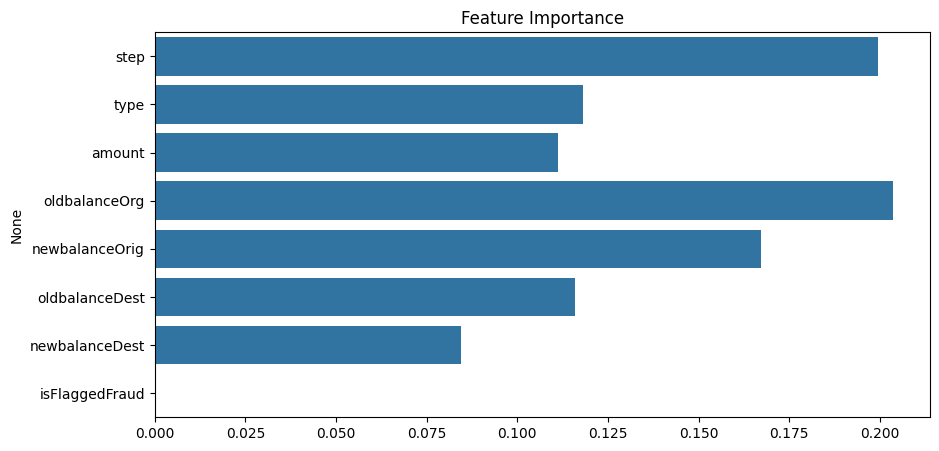


Model and Scaler saved successfully in 'processed' folder.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Results log saved as: processed/results.txt


In [ ]:
# ===============================
# Fraud Detection using PaySim Dataset
# ===============================

# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
import joblib

# 2. Load Dataset safely (skip malformed rows)
df = pd.read_csv("creditcard.csv", on_bad_lines='skip', low_memory=False)
print(f"Dataset loaded with shape: {df.shape}")

# 3. Basic Cleaning
# Drop unnecessary ID columns
df.drop(["nameOrig", "nameDest"], axis=1, inplace=True)

# Encode categorical column
le = LabelEncoder()
df["type"] = le.fit_transform(df["type"])

# 4. Convert numeric columns and coerce errors
num_cols = ["step", "amount", "oldbalanceOrg", "newbalanceOrig",
            "oldbalanceDest", "newbalanceDest", "isFlaggedFraud"]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows where target or numeric columns have NaNs
df = df.dropna(subset=num_cols + ["isFraud"])

# Ensure target is integer
df["isFraud"] = df["isFraud"].astype(int)

# Fill any remaining NaNs in features with 0
df.fillna(0, inplace=True)

# 5. Create 'processed' folder if it doesn't exist
processed_folder = "processed"
if not os.path.exists(processed_folder):
    os.makedirs(processed_folder)

# Save processed dataset
processed_file_path = os.path.join(processed_folder, "processed.csv")
df.to_csv(processed_file_path, index=False)
print(f"\nProcessed dataset saved to {processed_file_path}")

# 6. Check class imbalance
print("\nFraud Distribution:")
print(df["isFraud"].value_counts())

# 7. Feature & Target Split
X = df.drop("isFraud", axis=1)
y = df["isFraud"]

# 8. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 9. Handle Imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

# 10. Feature Scaling
scaler = StandardScaler()
X_train_smote = scaler.fit_transform(X_train_smote)
X_test = scaler.transform(X_test)

# 11. Model Training
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_smote, y_train_smote)

# 12. Predictions
y_pred = model.predict(X_test)

# 13. Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 14. Feature Importance
importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10,5))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")

# Save the plot as PNG in processed folder
feature_plot_path = os.path.join(processed_folder, "feature_importance.png")
plt.savefig(feature_plot_path, bbox_inches='tight')
print(f"\nFeature importance plot saved as {feature_plot_path}")

plt.show()

# 15. Save Model & Scaler
joblib.dump(model, os.path.join(processed_folder, "fraud_model.pkl"))
joblib.dump(scaler, os.path.join(processed_folder, "scaler.pkl"))

print(f"\nModel and Scaler saved successfully in '{processed_folder}' folder.")

# Optional: download files in Colab
try:
    from google.colab import files
    files.download("processed/processed.csv")
    files.download("processed/fraud_model.pkl")
    files.download("processed/scaler.pkl")
    files.download("processed/feature_importance.png")
except:
    pass

# ===============================
# Generate results.txt log
# ===============================
results_file = os.path.join(processed_folder, "results.txt")

with open(results_file, "w") as f:
    f.write("📌 Fraud Detection using PaySim Dataset\n\n")

    # Dataset info
    f.write("📊 Dataset Info:\n")
    f.write(f"Total records processed: {df.shape[0]}\n")
    f.write(f"Total features: {df.shape[1]}\n\n")

    # Class distribution
    f.write("⚖️ Class Distribution:\n")
    f.write("Original (before SMOTE):\n")
    f.write(f"{y.value_counts().to_string()}\n")
    f.write("After SMOTE (training data):\n")
    f.write(f"{pd.Series(y_train_smote).value_counts().to_string()}\n\n")

    # Model accuracy
    f.write("📈 Model Evaluation:\n")
    f.write(f"Accuracy: {accuracy:.4f}\n\n")

    # Classification report
    f.write("📝 Classification Report:\n")
    f.write(classification_report(y_test, y_pred))
    f.write("\n\n")

    # Confusion matrix
    f.write("🧮 Confusion Matrix:\n")
    f.write(f"{confusion_matrix(y_test, y_pred)}\n\n")

    # Top 5 important features
    f.write("⭐ Top 5 Features by Importance:\n")
    top_features = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(5)
    for i, (feat, score) in enumerate(top_features.items(), 1):
        f.write(f"{i}. {feat} ({score:.4f})\n")

    f.write("\n✅ All processed files are saved in the 'processed/' folder.\n")

print(f"Results log saved as: {results_file}")